# Working with complicated dataset


Your name: Anthony Kieu (017517565)

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [53]:
import pandas as pd
comp_df = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

In [54]:
### Your code here . . .
import urllib.request

with urllib.request.urlopen(comp_df) as response:
  for i in range(20):
    line = response.readline().decode('utf-8').strip()
    print(f"{i + 1}: {line}")


1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,
6: "# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,
7: # 100 hits found,,,,,,,,,,,,,,,
8: YP_220550.1,NP_904328.1,100,318,0,0,1,318,1,318,0,629,100," 1,487 ",9,
9: YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100," 17,947 ",47,
10: YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100," 12,106 ",13,
11: YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69," 2,319 ",41,
12: YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100," 18,964 ",3,
13: YP_220550.1,AEN03421.1,99.686,318,1,0,1,318,1,318,0,626,99.69," 12,444 ",39,
14: YP_220550.1,6G2J_H,100,317,0,0,2,318,2,318,0,62

In [55]:
#the first column name isn't used so I just dropped it
col_names = ["subject acc.ver","% identity", "alignment length", "mismatches", "gap opens", "q. start", "q. end", "s. start", "s. end", "evalue", "bit score", "% positives", "bonds", "publications"]

#read_csv with range(1,15) for usecols since the first column is dropped
dataset = pd.read_csv(comp_df,
                      skiprows=7,
                      header = None,
                      names = col_names,
                      usecols= range(1,15),
                      index_col = 'subject acc.ver',
                      thousands = ",",
                      na_values=['-'])
dataset.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0


### Question 2
What is the average number of publications?

In [56]:
dataset.publications.mean()
#The average number of publications is 26.98 (rounded up to 27) publications

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [57]:
dataset[(dataset['bonds'] > 15000)].index.tolist()
#the .index part just gives the indices of the rows where bonds are > 15000, tolist gives it in a list format

['AGK29621.1',
 'AHG32084.1',
 '6G2J_H',
 'YP_002791042.1',
 'AGK29634.1',
 '0806162F',
 'YP_009112408.1',
 'YP_001876469.1',
 'YP_009092269.1',
 'AHG32149.1',
 'YP_009092074.1',
 'YP_009450474.1',
 'YP_004123270.1',
 'YP_009092073.1',
 'AHZ60901.1',
 'YP_004123350.1',
 'YP_009453754.1',
 'ADD46492.1',
 'YP_007025968.1',
 'YP_009453806.1',
 'YP_007024956.1',
 'ASM92364.1',
 'YP_006073044.1',
 'ASM92494.1',
 'ADG95699.1',
 'YP_004891275.1',
 'YP_009166014.1',
 'YP_009538416.1',
 'YP_009414182.1',
 'YP_009178854.1',
 'YP_009414415.1',
 'YP_009353908.1',
 'YP_009093743.1',
 'ABX45285.1',
 'YP_009414156.1',
 'YP_009414363.1']

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

In [58]:
### Your code here . . .
import seaborn as sns

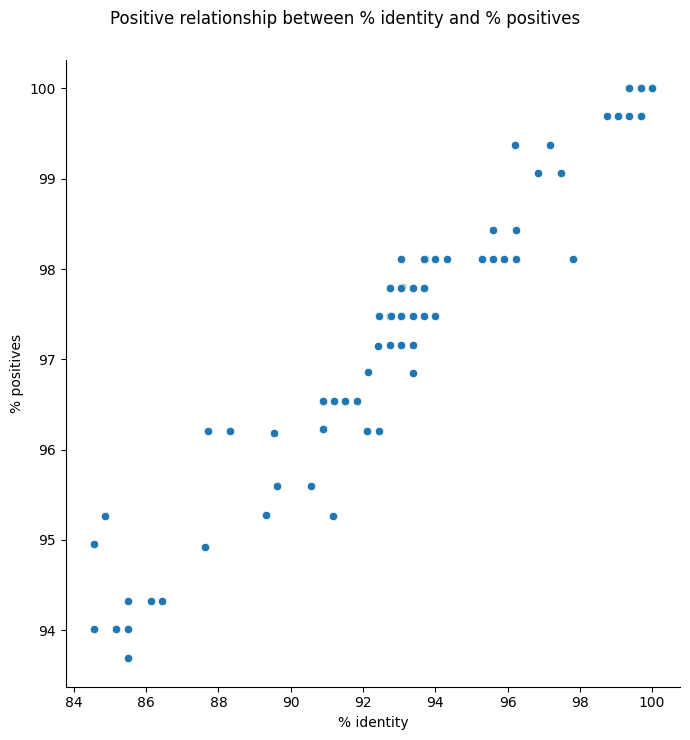

In [62]:
graph = sns.relplot(
    data = dataset,
    x = "% identity",
    y = "% positives",
    height = 7
)
graph.fig.suptitle("Positive relationship between % identity and % positives", y = 1.05);

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [65]:
### Your code here . . .
protein = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv",
                      na_values = ["NA"])
protein = protein.set_index(["Protein"])
protein = protein.drop("Unnamed: 0", axis = 1)

dataset['Protein Source'] = protein
dataset['Protein Source'] = dataset['Protein Source'].fillna("NA")
dataset.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein Source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NA
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NA
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NA
